## 03.07 교란편향
- **교란은 편향의 주요 원인**
- **교란은 대게 비인과적으로 연관성이 흐르는 백도어가 있을 때 발생**

    **이는 일반적으로 처치와 결과가 공통 원인을 공유하기 때문**

    - 예) HR 부서에서 새로운 관리 교육 프로그램이 관리자의 참여도를 높이는지 알고 싶을 때
        - 교육은 선택사항이므로, 교육이 필요한 관리자는 참석하지 않는 경향
        - 교육을 수강한 관리자들의 팀 참여도를 측정하면, 교육에 참여하지 않은 관리자들의 팀보다 참여도가 높음

        - **처치 (교육)이 결과 (참여도)에 얼마나 인과적인지 알기 어려움**

            처치와 결과 사이에 공통 원인이 있으며, 인과효과와 관계없이 함께 움직일 것이기 때문
        
<br>

- **인과효과를 식별하기 위해서는 처치와 결과 사이의 모든 백도어를 닫아야 함**
    
    $\rightarrow$ **교란편향을 보정하려면 처치와 결과 사이의 공통 원인의 보정이 필요**
- 하지만 모든 공통 원인은 항상 보정할 수 없음
    - 원인을 알 수 없거나, 원인을 알지만 측정할 수 없을 때도 있기 때문 (예: 정성적 요인 등)



In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import graphviz as gr
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
import networkx as nx

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

pd.set_option('display.max_rows', 6)

gr.set_default_format("png");

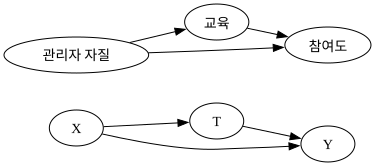

In [3]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("X", "T")
g.edge("X", "Y")
g.edge("T", "Y")

g.edge("관리자 자질", "교육"),
g.edge("관리자 자질", "참여도"),
g.edge("교육", "참여도")

g

<br>

### 01. 대리 교란 요인 (Surrogate Confounder)
- **측정 되지 않은 교란 요인으로 인하여, 대리변수로 사용할 수 있는 다른 측정된 변수들**
    
    (백도어 경로에는 없지만, 통제하면 편향을 줄이는데 도움이 될 수 있음 (다만, 완전히 편향을 제거하지는 못함))

    $\rightarrow$ **대리 교란 요인**

    - 예) 관리자의 자질을 측정할 수는 없지만, 관리자의 근속 기간이나 교육 수준과 같은 원인과 팀의 이직률 같은 영향은 측정 가능

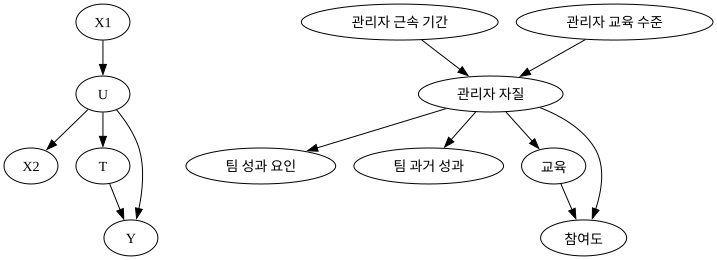

In [4]:
g = gr.Digraph()
g.edge("X1", "U")
g.edge("U", "X2")
g.edge("U", "T")
g.edge("T", "Y")
g.edge("U", "Y")

g.edge("관리자 자질", "팀 성과 요인")
g.edge("관리자 자질", "팀 과거 성과")
g.edge("관리자 근속 기간", "관리자 자질")
g.edge("관리자 교육 수준", "관리자 자질")

g.edge("관리자 자질", "교육")
g.edge("교육", "참여도")
g.edge("관리자 자질", "참여도")

g

<br>

### 02. 랜덤화 재해석
- 실무에서는 처치를 배정하는 데 어떤 정보를 사용했는지 알기 때문에, 교란 요인이 무엇인지 파악하기가 쉬움
    
    그렇지 않은 경우에도 처치변수에 개입할 수 있는 옵션이 거의 항상 존재

    $\rightarrow$ AB테스트의 핵심

<br>

- **처치를 무작위로 배정하면, 관측할 수 없는 교란요인이 있는 그래프에서 처치의 유일한 원인이 랜덤성인 그래프로 바꿀 수 있음**

    $\rightarrow$ **결과적으로 어떤 변수를 조건부로 두어야 효과를 식별할 수 있는지 확인하려고 노력하면서, 관심 있는 인과 추정량을 식별 가능한 그래프로 바꿔주는 개입이 어떤 것인지 확인 필요**

    $\rightarrow$ **랜덤화 = 교란요인의 영향을 제거하도록 그래프 구조를 강제로 바꾸는 인위적 개입 $\rightarrow$ 인과 추정이 쉽게 됨**

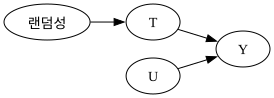

In [5]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("랜덤성", "T")
g.edge("T", "Y")
g.edge("U", "Y")

g

<br>

#### 민감도 분석 (Sensitivity Analysis)과 부분 식별 (Partial Identification)
- 모든 공통 원인을 측정할 수 없을 때,

    '모든 교란요인을 측정하고 있는가'가 아닌 '측정되지 않은 교란 요인이 분석 결과를 크게 바꾸려면 얼마나 강력해야 하는가'로 사고를 전환

    $\rightarrow$ **민감도 분석**

<br>

- 관심 있는 인과 추정량을 정확히 식별할 수 없을 때도 관측 가능한 데이터를 사용하여 그 주변에 경계를 설정

    $\rightarrow$ **부분 식별**

<br>

<hr>

<br>

## 03.08 선택편향

| 구분    | 교란편향(confounding)                 | 선택편향(selection bias)             |
| - | - | -  |
| 원인 | **공통 원인(Confounder)** 를 통제하지 않아 발생 | **충돌부(Collier)** 를 통제해서 발생 |
| 발생 순간 | **제어(통제)를 하지 않을 때**               | **제어(통제)를 했을 때**                 |
| 경로    | 백도어 경로가 열림                   | 충돌부 조건화로 가짜 경로가 열림 |
| 해결    | 공통 원인를 통제                    | 충돌부를 통제하지 않음 (즉 선택을 피함)      |


<br>

### 01. 충돌부 조건부 설정

- 소프트웨어 회사에서, 신규 기능의 영향을 평가

> 교란편향을 피하려고 무자구이로 고객들에게 기능을 배포 (처치)
>
> 고객중 10%는 무작위로 신규기능을 사용하고, 나머지는 그렇지 않음
>
> 이 기능이 고객의 만족도와 행복감을 높였는지 알고 싶으며, 순고객추천지수 (NPS)를 대리변수로 사용 가능
>
> NPS를 측정하기 위해서, 실험군과 대조군에 설문을 보냈지만, 
>
> **신규 기능을 사용하고 NPS에 응한 고객들이, 신규 기능을 사용하지 않고 NPS설문에도 응한 고객들보다, NPS점수가 더 높음을 알게 됨**

$\rightarrow$ 이 차이는 신규 기능이 NPS에 미친 인과효과라고 할 수 있는가?


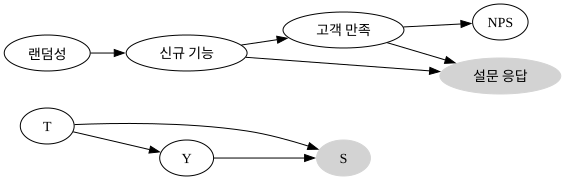

In [6]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.edge("T", "S")
g.edge("T", "Y")
g.edge("Y", "S")
g.node("S", color="lightgrey", style="filled")

g.edge("랜덤성", "신규 기능")
g.edge("신규 기능", "고객 만족")
g.edge("고객 만족", "NPS")
g.edge("고객 만족", "설문 응답")
g.edge("신규 기능", "설문 응답")
g.node("설문 응답", color="lightgrey", style="filled")

g

- **설문 응답은 충돌부이며, 두 변수 (신규 기능, 고객 만족)의 공통 결과**

    $\rightarrow$ **충돌부를 조건화 하면 부모 노드 (신규 기능, 고객 만족)들은 서로 종속** 

    $\rightarrow$ **고객 만족 $\leftrightarrow$ 신규 기능 이라는 비인과 경로 생성**

    $\rightarrow$ **그 경로를 통해 기존에 없던 ‘신규 기능 → NPS’ 간의 가짜 연관성이 생기며, 이는 선택편향 발생**

In [7]:
model = nx.DiGraph([
    ("랜덤성", "신규 기능"),
    ("신규 기능", "고객 만족"),
    ("고객 만족", "NPS"),
    ("고객 만족", "설문 응답"),
    ("신규 기능", "설문 응답"),
])

T = {"신규 기능"}
Y = {"NPS"}
S = {"설문 응답"}  

print("설문 응답이 주어진 경우, 신규 기능과 NPS는 종속?", not nx.d_separated(model, T, Y, S))

설문 응답이 주어진 경우, 신규 기능과 NPS는 종속? True


<br>


- 충돌부를 조건화하면, 실험군과 대조군은 '다른 종류의 사람들'로 구성

    $\rightarrow$ 실험군-대조군 평균 차이는 ATE가 아니라, ATE + 선택편향으로 분해됨

    $\rightarrow$ **실험군과 대조군간의 평균 차이만으로는 ATE를 식별할 수 없음**

    **만족한 고객일수록 설문 응답할 가능성이 높음 $\rightarrow$ 설문에 응답한다는 것 자체가, 이미 만족도의 함수이기 때문**

    - 대조군 (T=0)의 응답자 구성
        - 원래 만족도가 높음
        - 원래 만족도가 낮은 고객은 응답 X

        $\rightarrow$ **원래 만족도가 높은 사람들로 편향**

    - 실험군 (T=1)의 응답자 구성
        - 원래 만족도가 높음 
        - 원래 만족도는 낮았지만, 신규 기능 (T=1)로 인해 만족도가 올라서 응답한 사람 

    $\rightarrow$ **충돌부 조건화로 인하여 ATE는 진짜 인과효과보다 더 크게 보일 수 있음**

$$
E[Y|T=1, S=1] - E[Y|T=0, S=1] = \underbrace{E[Y_1 - Y_0|S=1]}_{ATE} + \underbrace{\{ E[Y_0|T=1, S=1] - E[Y_0|T=0, S=1] \}}_{선택편향}
$$


<br>

### 02. 선택편향 보정
- **선택($S$)에 결과($Y$)가 영향을 주지 않는다고 가정하면, 선택편향을 해결 가능 ($Y$ $\not \rightarrow$ $S$)**

    **$S$가 $Y$의 결과가 아니라, 다른 관측변수 $X$의 결과라면, $X$를 통제함으로써 선택편향을 막을 수 있음**



<br>

- **선택 $S$를 조건으로 두더라도, 결과 $Y$가 $S$를 직접 결정하지 않고, 관측 변수 $X$가 $S$와 $Y$를 모두 결정한다면,**

    **$X$로 층화하면 선택편향을 제거할 수 있음**

$$
ATE = \sum_x \{(E[Y | T=1,S=1, X] - E[Y|T= 0, S=1, X]) P(X | S=1) \}
$$



<br>

- 아래 그래프에서 $S$는 많은 요인들의 결과
    - $T \rightarrow S$ (처치가 선택을 유발)
    - $Y \rightarrow S$ (결과가 선택을 유발)
    - $U \rightarrow S$ (숨겨진 요인도 선택을 유발)
    - $X3 \rightarrow S, X4 \rightarrow S, X5 \rightarrow S$ (측정 가능한 요인들이 선택을 유발)

    이 경우, $S=1$ (응답한 사람)만 분석하는 건 매우 위험

- $S$를 조건화하면 충돌부가 열려, 이 모든 부모 노드($T, Y, U, X3, X4, X5$) 사이에 비인과 연관성이 생김
    - 이 중 $X3, X4, X5$는 측정된 변수

- **일반적으로 선택편향을 보정하려면 선택 ($S$)을 유발하는 모든 요인을 알고 있어야 하며,**

    **$S$가 $Y$의 결과가 아니고, $S$가 $T$의 결과가 아니어야 하며, $S$가 $U$의 결과여서도 안 됨**

- $X3, X4, X5$의 관측된 요인들은 $S$의 원인이므로, 통제하면 일부 편향은 줄일 수 있으나,

    $Y \rightarrow S \leftarrow T$, $T \rightarrow S \leftarrow U \rightarrow Y$의 (점선) 경로들은 절대 제거할 수 없음

    $\rightarrow$ **선택을 설명하는 변수를 조건으로 두는 것은 편향을 줄일 수 있지만**, 
        
    **알 수 없거나 측정할 수 없는 선택의 원인이 있고, 결과나 처치가 직접적으로 선택의 원인이라면, 편향을 완전히 없애지는 못함**

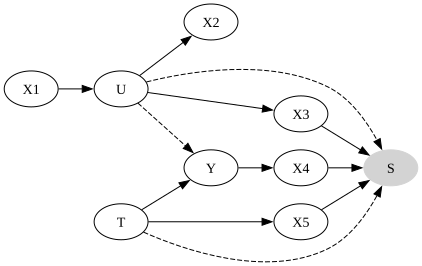

In [9]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})

g.edge("X1", "U")
g.edge("U", "X2")
g.edge("X5", "S")
g.edge("U", "Y",style="dashed")
g.edge("U", "S",style="dashed")
g.edge("U", "X3")
g.edge("X3", "S")
g.edge("Y", "X4")
g.edge("X4", "S")
g.edge("T", "X5")
g.edge("T", "Y")
g.edge("T", "S", style="dashed")
g.node("S", color="lightgrey", style="filled")

g

<br>

- 또한, 선택을 유발하는 모든 변수를 통제하는 방법이 항상 도움되지는 않음
    - 아래의 그래프에서 $X$를 조건부로 두면, 비인과 경로 $Y \rightarrow X \leftarrow T$가 열림

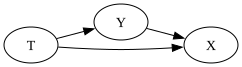

In [ ]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})

g.edge("Y", "X")
g.edge("T", "X")
g.edge("T", "Y")

g

<br>

#### 생존자 선택편향
- 생존분석은 지속 기간이나 사건 발생까지의 시간을 포함하는 많은 비즈니스 사례에서 활용
    - 예) 은행의 목표는 대출 금액이 $P(채무불이행|yr=1), P(채무불이행|yr=2), P(채무불이행|yr=3)$에 미치는 영향을 파악하는 것
    - 은행이 대출 금액을 무작위로 배정했다고 해도, 
        
        1년 동안 생존 (대출 상환)한 고객만 2년 차에 채무불이행 여부가 관측되고, 1, 2년차 모두 살아남은 사람만 3년차를 관측

        **즉, 관측 가능한 집단이 시간이 갈수록 필터링**

        $\rightarrow$ **선택되는 생존자 집단 : 생존자 선택편향**
    - 대출금액이 클수록 채무불이행 위험이 증가한다면

        위험이 높은 사람들은 초기에 탈락, 위험이 낮은 사람들은 나중 시점까지 생존

        **2, 3년차에 관측되는 사람들은 원래 채무불이행 위험이 낮은 사람들만 남는 편향된 표본**

        **이 표본에서 대출 금액의 효과를 측정하면, 위험도가 낮은 생존자 집단에서는 '대출이 커도 잘 버티는 사람들'만 남아있을 수 있음** $\rightarrow$ **대출 금액이 커도 채무불이행이 줄어든 듯 보이기도 함**

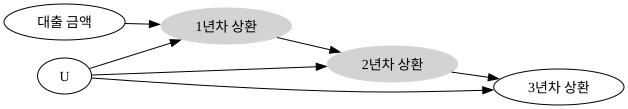

In [16]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})

g.edge("대출 금액", "1년차 상환")
g.node("1년차 상환", color="lightgrey", style="filled")
g.edge("1년차 상환", "2년차 상환")
g.node("2년차 상환", color="lightgrey", style="filled")
g.edge("2년차 상환", "3년차 상환")

g.edge("U", "1년차 상환")
g.edge("U", "2년차 상환")
g.edge("U", "3년차 상환")

g

<br>

- **연간 결과 (위험율 = $채무불이행 | yr = t$)가 아닌, 누적 결과 (생존율 = 채무불이행 | yr > t)은 연간 생존 인원을 기준으로 계산 (조건화)가 아니라 전체 배정 인원을 기준으로 계산되기에**

    **누적 생존효과는 식별 가능**

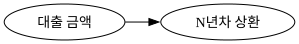

In [15]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})

g.edge("대출 금액", "N년차 상환")
g



<br>

### 03. 매개변수 조건부 설정 편향 (Mediator Bias)
- 예) 동일 자격, 동일 조건에서 '성별'이 임금에 미치는 영향(총 효과)이 궁금

    $T \rightarrow Y$의 인과효과 (총 효과)를 알고 싶음

<br>

- **만약 매개변수 ($M$)인 직급을 조건화하면**

    **직급 (승진)에 대한 성별의 효과를 제거 $\rightarrow$ 성별이 임금에 미치는 전체적인 효과를 왜곡할 수 있음**

    $\rightarrow$ **매개변수 조건부 설정의 편향**


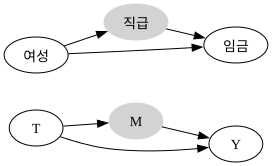

In [19]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.edge("T", "M")
g.edge("T", "Y")
g.edge("M", "Y")
g.node("M", color="lightgrey", style="filled")

g.edge("여성", "직급")
g.edge("여성", "임금")
g.edge("직급", "임금")
g.node("직급", color="lightgrey", style="filled")

g

- 또한, 매개변수의 자식변수가 조건부로 주어지면 편향이 발생

    이는 인과경로를 완전히 차단하지는 않지만 부분적으로 차단

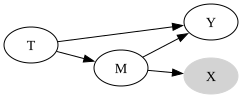

In [20]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.edge("T", "M")
g.edge("T", "Y")
g.edge("M", "Y")
g.edge("M", "X")
g.node("X", color="lightgrey", style="filled")

g

<br>

<hr>